In [1]:
import anndata as an
import scanpy as sc
import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import gget

import seaborn as sns
import matplotlib.pyplot as plt

sc.settings.verbosity = 3

In [2]:
fpaths = {
    'epi2me' : "/scratch/indikar_root/indikar1/shared_data/epi2me_pipeline_run/outputs/full_reads_run_mar_19/32f7539deda847c0a5dc4405f98ebd86/32f7539deda847c0a5dc4405f98ebd86.gene_raw_feature_bc_matrix/",
    'hybrid' : "/scratch/indikar_root/indikar1/shared_data/lib2_02262025/anndata/anndata.raw.h5ad",
}

def clean_anndata(adata):
    """Removes rows and columns with NaN or Inf from AnnData's .X."""
    data = adata.X
    mask = np.isfinite(data)
    row_mask = mask.all(axis=1)
    col_mask = mask.all(axis=0)

    filtered_data = data[row_mask][:, col_mask] # filter rows, then columns
    
    adata = adata[row_mask, col_mask] #filter adata object.
    adata.X = filtered_data
    return adata


datas = {}

for key, fpath in fpaths.items():
    if key == 'epi2me':
        tdata = sc.read_10x_mtx(fpath)
    else:
        tdata = sc.read_h5ad(fpath)
    tdata.obs['batch'] = key
    tdata.obs_names = [f"{x}_{key}" for x in tdata.obs_names] # make sure ids are consistent

    if key == 'hybrid':
        tdata.var_names = tdata.var['gene_name'].values
        tdata = tdata[:, tdata.var['gene_biotype'] == 'protein_coding'].copy()

    tdata.X = tdata.X.toarray()
    datas[key] = clean_anndata(tdata)

    print(f"Batch: {key}")
    print(f"\tTotal UMIs: {int(np.sum(tdata.X))}")
    print(f"\tCells: {tdata.shape[0]}")
    print(f"\tGenes: {tdata.shape[1]}")

    df = tdata.to_df()
    print(f"\tMean reads per cell: {int(df.sum(axis=1).mean())}")
    print(f"\tMean reads per gene: {int(df.sum(axis=0).mean())}")

    df_bool = df.astype(bool)
    
    print(f"\tMean genes per cell: {int(df_bool.sum(axis=1).mean())}")
    print(f"\tMean cells per gene: {int(df_bool.sum(axis=0).mean())}")

print("ready!")

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Batch: epi2me
	Total UMIs: 85851360
	Cells: 10886
	Genes: 24125
	Mean reads per cell: 7886
	Mean reads per gene: 3558
	Mean genes per cell: 2747
	Mean cells per gene: 1239
Batch: hybrid
	Total UMIs: 102416336
	Cells: 11641
	Genes: 19400
	Mean reads per cell: 8797
	Mean reads per gene: 5279
	Mean genes per cell: 2589
	Mean cells per gene: 1554
ready!


In [3]:
# break

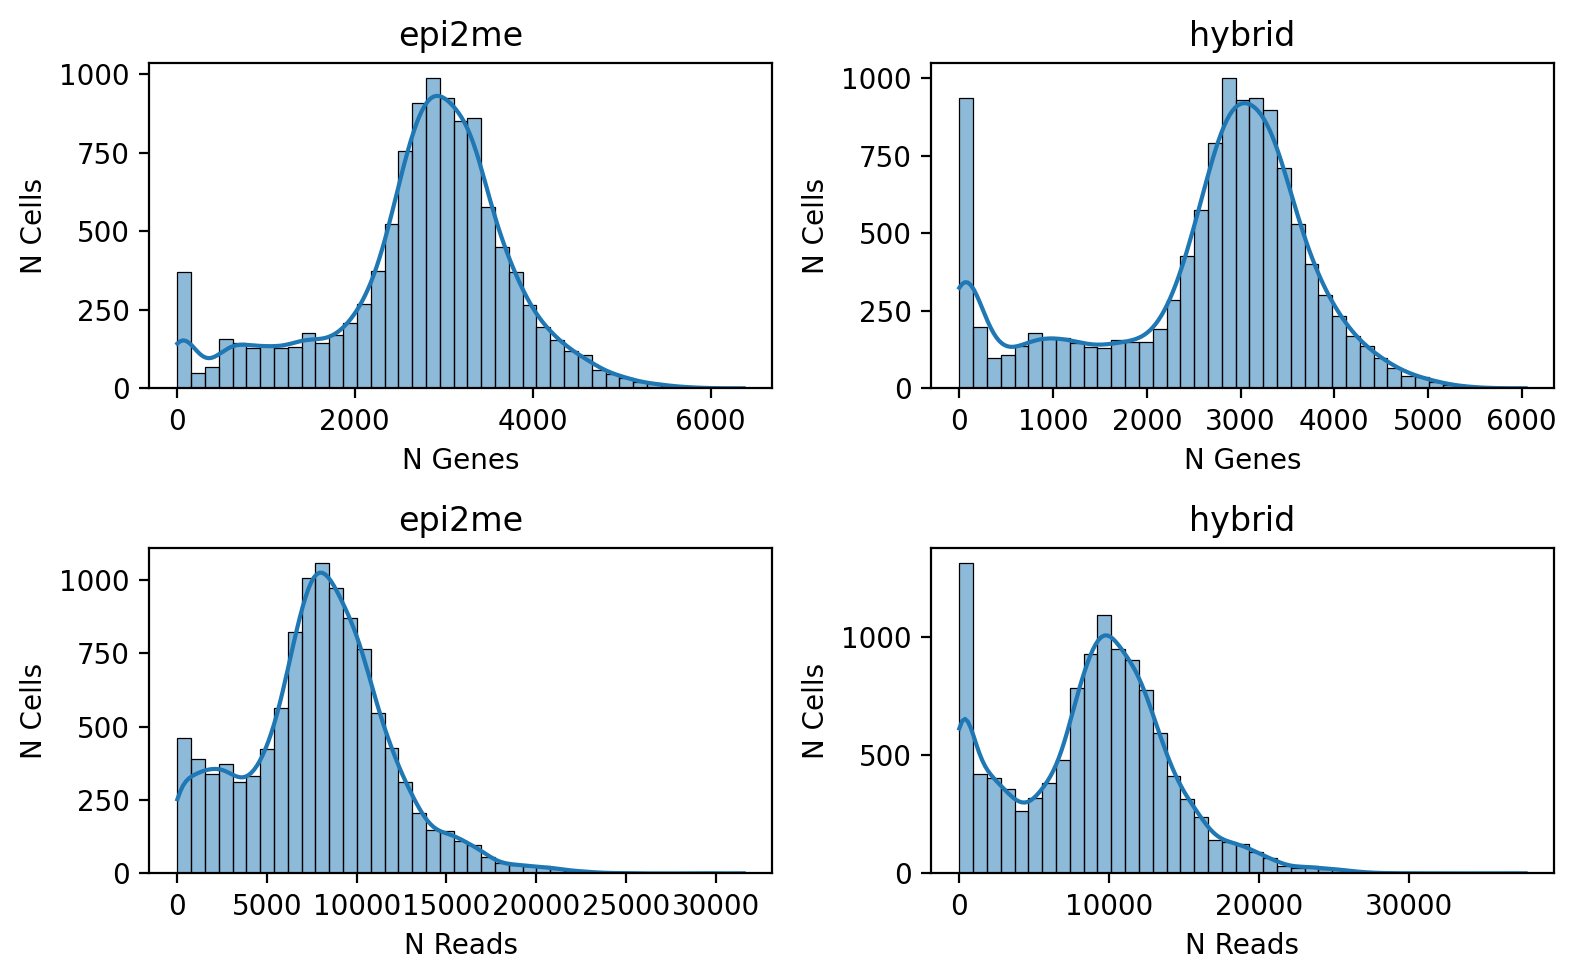

In [4]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 5 
fig, axs = plt.subplots(2, 2)

i = -1
for key, adata in datas.items():
    i += 1

    n_reads = adata.X.sum(axis=1)
    n_genes = np.count_nonzero(adata.X, axis=1)

    """ GENES PER CELL """
    sns.histplot(
        x=n_genes,
        bins=41,
        kde=True,
        ax=axs[0, i],
    )

    axs[0, i].set_ylabel('N Cells')
    axs[0, i].set_xlabel('N Genes')
    axs[0, i].set_title(key)


    """ READS PER CELL """
    sns.histplot(
            x=np.ravel(n_reads),
            bins=41,
            kde=True,
            ax=axs[1, i],
        )

    axs[1, i].set_ylabel('N Cells')
    axs[1, i].set_xlabel('N Reads')
    axs[1, i].set_title(key)

plt.tight_layout()

In [5]:
for key, adata in datas.items():

    print(f"\n---- {key} ----")
    df = adata.to_df().sum(axis=0).sort_values(ascending=False)
    print(df.head(15))


---- epi2me ----
MALAT1     1395794.0
MT2A       1301470.0
TMSB10     1014892.0
LGALS1      949193.0
S100A6      781616.0
MT-RNR2     650204.0
IFITM3      647552.0
RPLP1       622289.0
IFITM1      537868.0
ISG15       531984.0
MT-CO1      485347.0
RPL28       423076.0
IFI6        410057.0
S100A11     384404.0
VIM         376104.0
dtype: float32

---- hybrid ----
MT2A       1830551.0
TMSB10     1416511.0
LGALS1     1341002.0
S100A6     1106068.0
IFITM3      904977.0
RPLP1       898443.0
ISG15       760496.0
RPS8        685553.0
RPS12       680521.0
MT-CO1      652671.0
RPL28       616975.0
MT-CO2      613674.0
VIM         546447.0
S100A11     545478.0
FTH1        543496.0
dtype: float32


# Single-cell matching

Text(0.5, 1.0, 'Total UMIs per Cell')

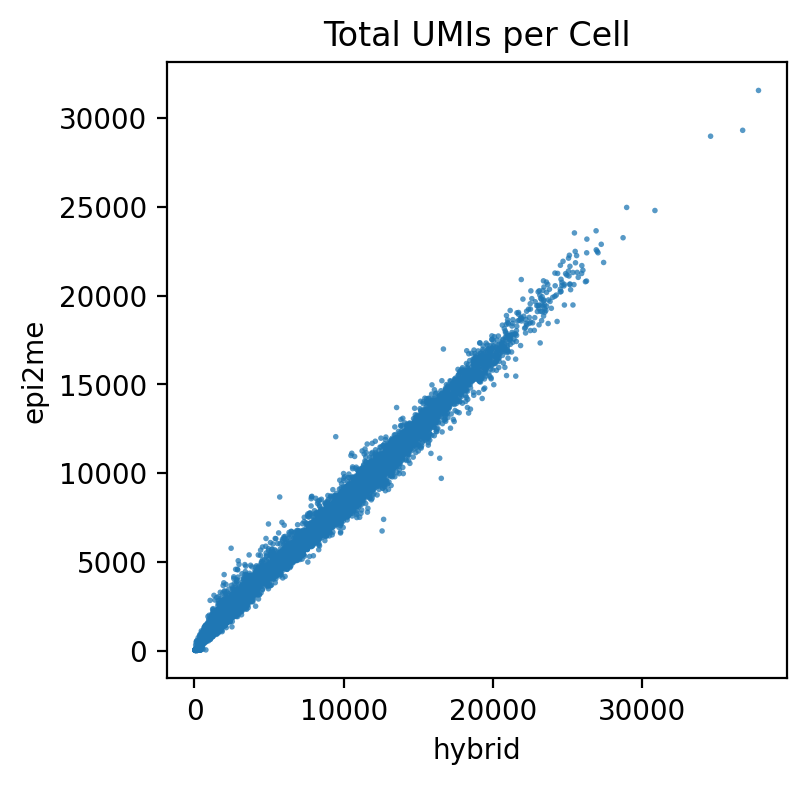

In [6]:
result = [] 

for key, adata in datas.items():
    df = adata.to_df().sum(axis=1).sort_values(ascending=False)
    df.index = df.index.str.split('_').str[0].str.split('-').str[0]
    df.name = key
    result.append(df)

result = pd.concat(result, axis=1, ignore_index=False)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sns.scatterplot(
    data=result,
    x='hybrid',
    y='epi2me',
    ec='none',
    alpha=0.75, 
    s=4,
)

plt.title("Total UMIs per Cell")

Text(0.5, 1.0, 'Non-zero Genes per Cell')

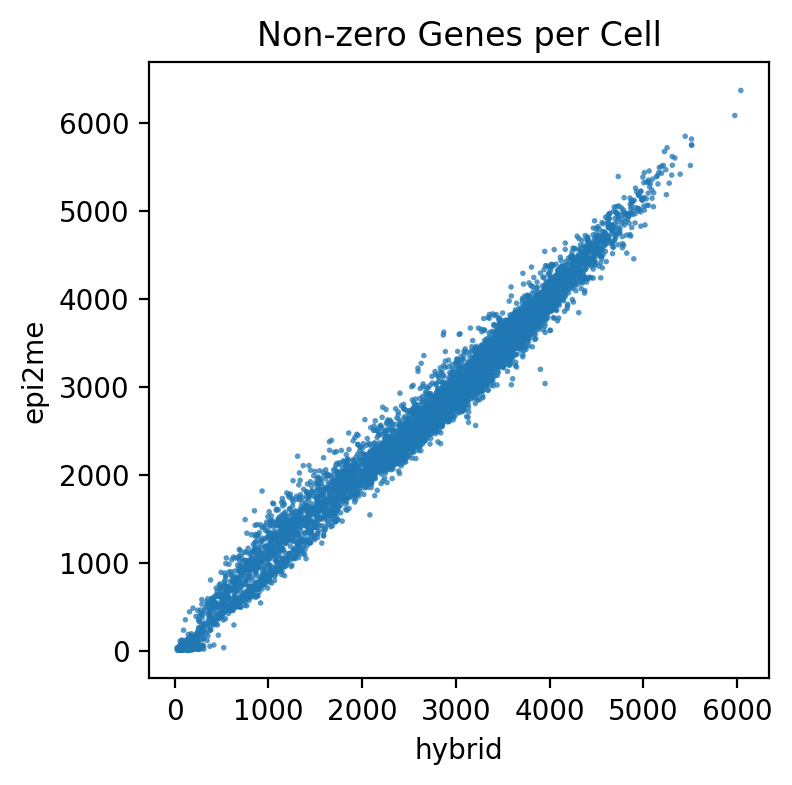

In [7]:
result = [] 

for key, adata in datas.items():
    df = adata.to_df()
    df.index = df.index.str.split('_').str[0].str.split('-').str[0]

    df = (df != 0).sum(axis=1)
    df.name = key
    result.append(df)

result = pd.concat(result, axis=1, ignore_index=False)

sns.scatterplot(
    data=result,
    x='hybrid',
    y='epi2me',
    ec='none',
    alpha=0.75, 
    s=4,
)

plt.title("Non-zero Genes per Cell")

# Basic workflow

epi2me
filtered out 323 cells that have less than 100 genes expressed
filtered out 1518 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
Updated shape epi2me: adata.shape=(10563, 22607)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:03)


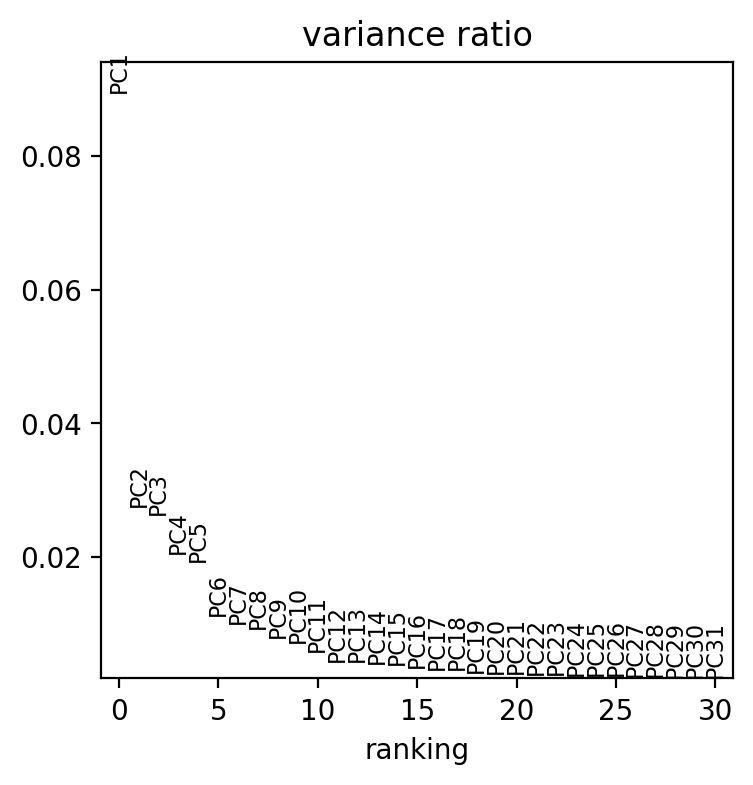

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:18)
running Leiden clustering


/tmp/ipykernel_1335323/3590189194.py:32: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.25)


    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


... storing 'batch' as categorical
... storing 'feature_types' as categorical


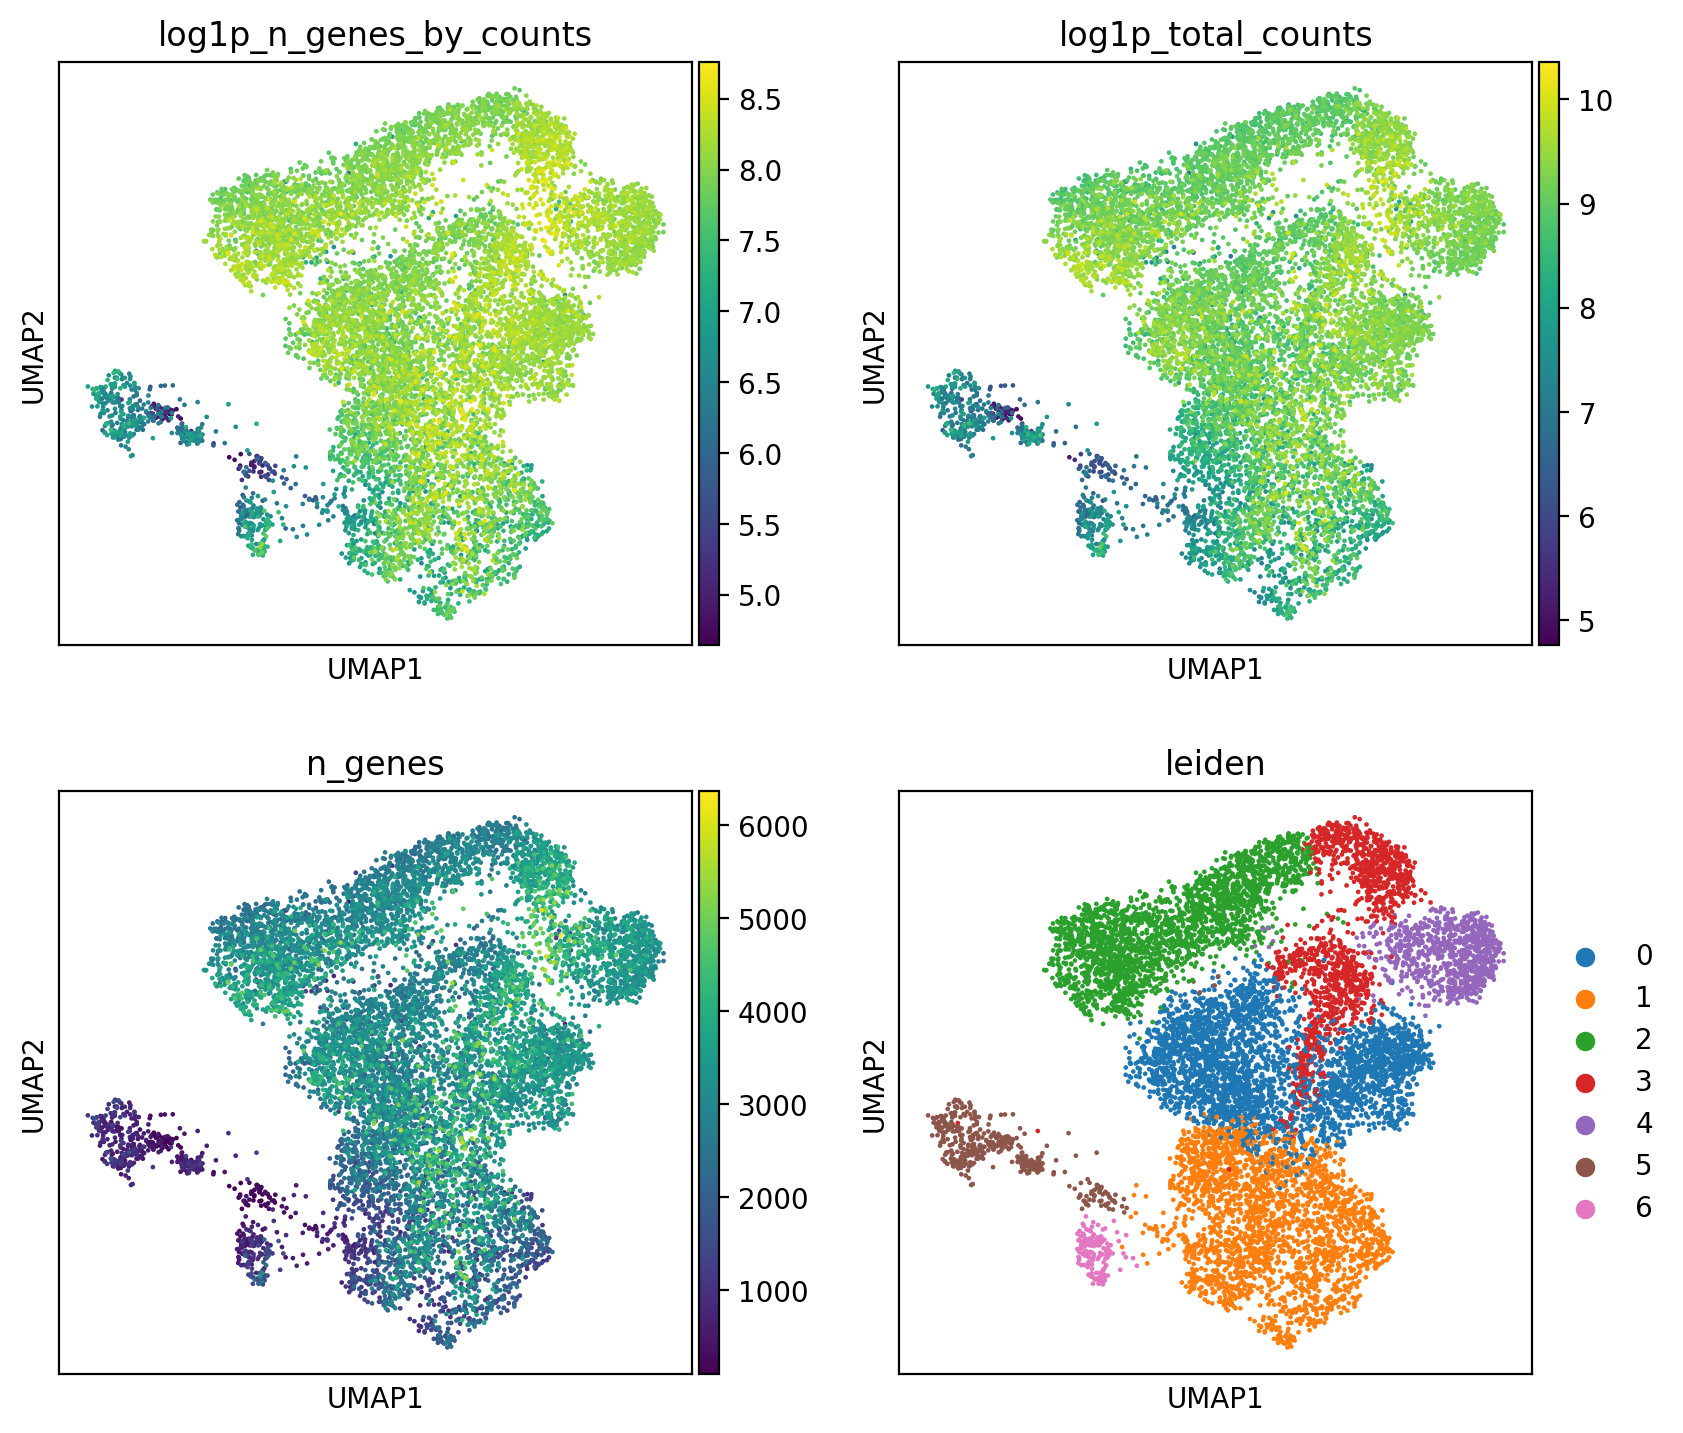

hybrid


/home/cstansbu/miniconda3/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_qc.py:431: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


filtered out 813 cells that have less than 100 genes expressed
filtered out 3977 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
Updated shape hybrid: adata.shape=(10828, 15423)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:03)


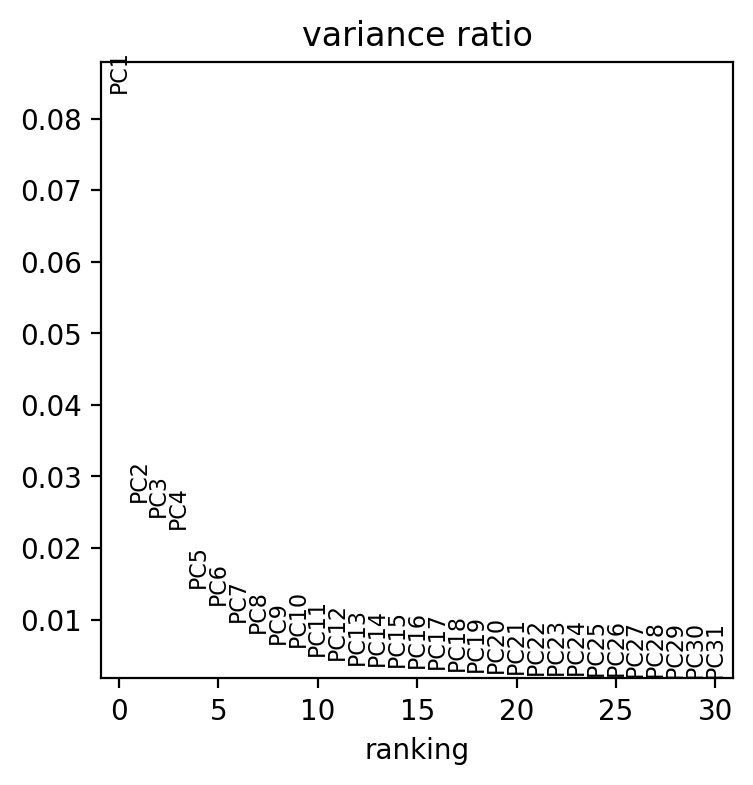

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
running Leiden clustering
    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)


... storing 'batch' as categorical


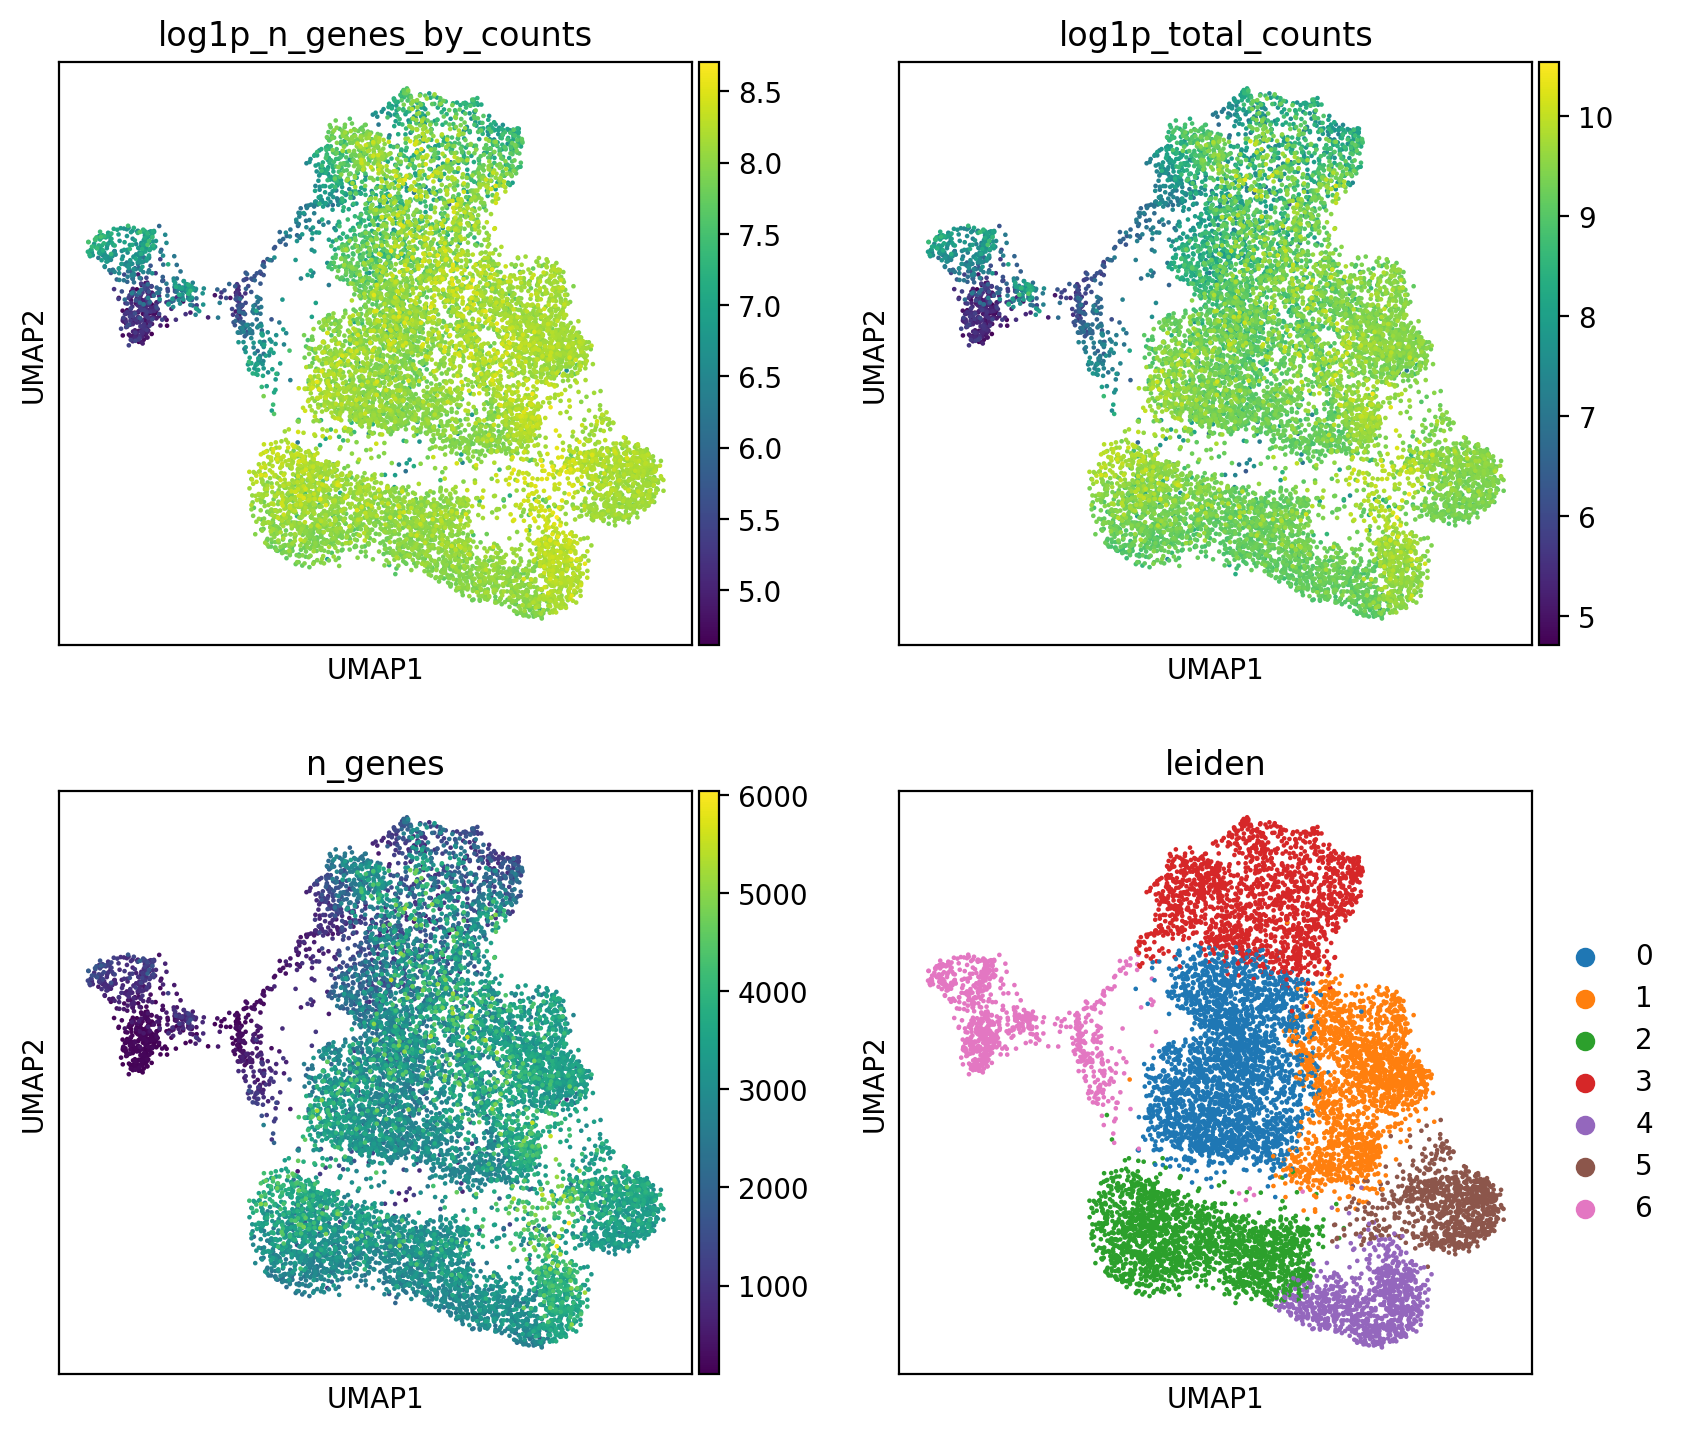

In [8]:
processed = {}
for key, bdata in datas.items():
    print(key)
    adata = bdata.copy()

    # mitochondrial genes, "MT-" for human, "Mt-" for mouse
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    # ribosomal genes
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    # hemoglobin genes
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

    sc.pp.calculate_qc_metrics(
        adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
    )

    sc.pp.filter_cells(adata, min_genes=100)
    sc.pp.filter_genes(adata, min_cells=3)

    adata.layers['counts'] = adata.X.copy()

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    print(f"Updated shape {key}: {adata.shape=}")

    sc.pp.highly_variable_genes(adata)
    sc.pp.pca(adata)
    sc.pl.pca_variance_ratio(adata)

    sc.pp.neighbors(adata)
    sc.tl.leiden(adata, resolution=0.25)
    sc.tl.umap(adata)
    sc.pl.umap(
        adata,
        ncols=2,
        color=[
            'log1p_n_genes_by_counts', 'log1p_total_counts',
            'n_genes', 'leiden'],
    )

    processed[key] = adata